In [1]:
%pip install matplotlib numpy h5py scipy scikit-learn

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 2.1 MB/s eta 0:00:02
   --------- ------------------------------ 0.8/3.2 MB 1.8 MB/s eta 0:00:02
   --------- ------------------------------ 0.8/3.2 MB 1.8 MB/s eta 0:00:02
   ---------------- ----------------------- 1.3/3.2 MB 1.4 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.3 MB/s eta 0:00:02
   -------------------------- ------------- 2.1/3.2 MB 1.5 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 1.6 MB/s eta 0:00:01
   ------------------------------------ --- 2.9/3.2 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 1.7 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import logistic

Sigmoid

Text(0.5, 1.0, 'Sigmoid Function')

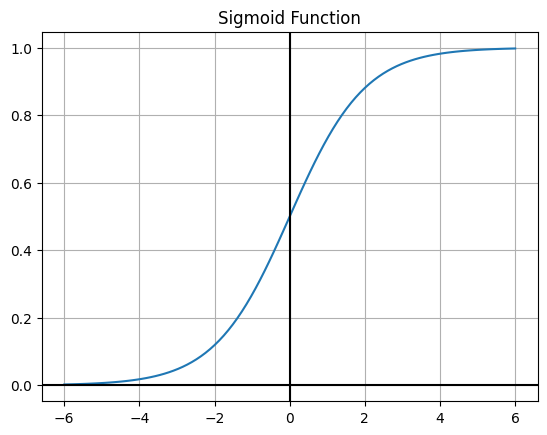

In [6]:
plt.figure()
x= np.linspace(-6,6,100)
y = logistic.cdf(x)
plt.plot (x,y)
ax= plt.gca()
#ax.set_aspect('equal')
ax.grid(True, which='both') 

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.title('Sigmoid Function')

Rectified Linear Unit (ReLU)

Text(0.5, 1.0, 'ReLU Function')

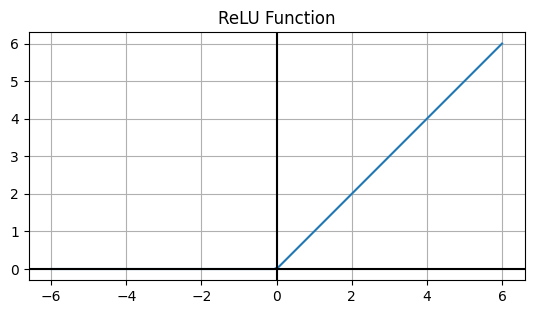

In [7]:
plt.figure()
x= np.linspace(-6,6,100)
y = np.maximum(x,0)
plt.plot (x,y)
ax= plt.gca()
ax.set_aspect('equal')
ax.grid(True, which='both') 

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.title('ReLU Function')

Leaky ReLU

Text(0.5, 1.0, 'Leaky ReLU Function')

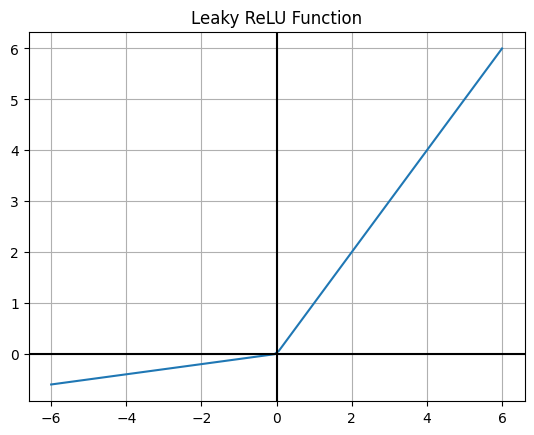

In [8]:
plt.figure()
x= np.linspace(-6,6,100)
y = np.maximum(x,0.1*x)
plt.plot (x,y)
ax= plt.gca()
# ax.set_aspect('equal')
ax.grid(True, which='both') 

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.title('Leaky ReLU Function')

Tanh

Text(0.5, 1.0, 'Tanh Function')

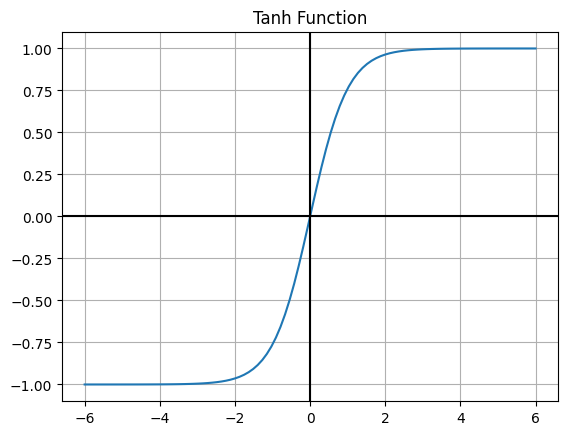

In [9]:
plt.figure()
x= np.linspace(-6,6,100)
y = np.tanh(x)
plt.plot (x,y)
ax= plt.gca()
# ax.set_aspect('equal')
ax.grid(True, which='both') 

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.title('Tanh Function')

HOME TASK

In [10]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y= True)
print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)

X.shape=  (569, 30)
y.shape=  (569,)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42, n_iter_no_change=10, alpha = 1)
clf.fit(X_train_scaled, y_train)

train_accuracy = clf.score(X_train_scaled, y_train)
test_accuracy = clf.score(X_test_scaled, y_test)

print("train accuracy= {:.3%}".format(train_accuracy))
print("test accuracy= {:.3%}".format(test_accuracy))

train accuracy= 99.341%
test accuracy= 98.246%


Signs Data Set

In [ ]:
import os
import h5py
def load_dataset():
    fn =  os.path.join("C:/Users/orban/Downloads", 'train_signs.h5')
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:])
    y_train = np.array(train_dataset["train_set_y"][:])

    fn =  os.path.join("C:/Users/orban/Downloads", 'test_signs.h5')
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:])
    y_test = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])
    
    y_train = y_train.reshape((1, y_train.shape[0]))
    y_test = y_test.reshape((1, y_test.shape[0]))
    
    return X_train, y_train, X_test, y_test, classes

X_train_orig, y_train_orig, X_test_orig, y_test_orig, classes = load_dataset()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

X_train_orig, y_train_orig, X_test_orig, y_test_orig, classes = load_dataset()

X_train_flatten = X_train_orig.reshape(X_train_orig.shape[0], -1)
X_test_flatten = X_test_orig.reshape(X_test_orig.shape[0], -1)

X_train = X_train_flatten / 255.
X_test = X_test_flatten / 255.

y_train = y_train_orig.ravel()
y_test = y_test_orig.ravel()

clf = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=0.1,
    batch_size=64,
    learning_rate_init=0.0001,
    max_iter=2000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

clf.fit(X_train, y_train)

train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print("-" * 30)
print(f"Train accuracy: {train_accuracy:.3%}")
print(f"Test accuracy: {test_accuracy:.3%}")

Iteration 1, loss = 3.09547091
Validation score: 0.120370
Iteration 2, loss = 2.92833800
Validation score: 0.305556
Iteration 3, loss = 2.80355536
Validation score: 0.203704
Iteration 4, loss = 2.68889943
Validation score: 0.444444
Iteration 5, loss = 2.58785324
Validation score: 0.379630
Iteration 6, loss = 2.49022029
Validation score: 0.509259
Iteration 7, loss = 2.45908409
Validation score: 0.546296
Iteration 8, loss = 2.31333994
Validation score: 0.462963
Iteration 9, loss = 2.20668347
Validation score: 0.546296
Iteration 10, loss = 2.20732802
Validation score: 0.425926
Iteration 11, loss = 2.14432600
Validation score: 0.537037
Iteration 12, loss = 2.08357844
Validation score: 0.611111
Iteration 13, loss = 2.02832410
Validation score: 0.509259
Iteration 14, loss = 2.00610384
Validation score: 0.592593
Iteration 15, loss = 1.92777217
Validation score: 0.611111
Iteration 16, loss = 1.84007953
Validation score: 0.638889
Iteration 17, loss = 1.78630409
Validation score: 0.564815
Iterat

In [14]:
import matplotlib.pyplot as plt
plt.gcf().canvas.manager.set_window_title('Train set')

<Figure size 640x480 with 0 Axes>

In [ ]:
# YOUR_CODE. Preprocess data
# START_CODE 

X_train_flatten = X_train_orig.reshape(X_train_orig.shape[0], -1) 
X_test_flatten = X_test_orig.reshape(X_test_orig.shape[0], -1)

X_train_scaled = X_train_flatten / 255.
X_test_scaled = X_test_flatten / 255.

Y_train_ready = y_train_orig.ravel() 
Y_test_ready = y_test_orig.ravel()

def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)].T
    return Y

Y_train_scaled = convert_to_one_hot(y_train_orig, 6)
Y_test_scaled = convert_to_one_hot(y_test_orig, 6)

clf.fit(X_train_scaled, Y_train_ready)

# END_CODE
print ("number of training examples = " + str(X_train_scaled.shape[1]))
print ("number of test examples = " + str(X_test_scaled.shape[1]))
print ("X_train_scaled shape: " + str(X_train_scaled.shape))

print ("X_test_scaled shape: " + str(X_test_scaled.shape))

Iteration 1, loss = 3.09547091
Validation score: 0.120370
Iteration 2, loss = 2.92833800
Validation score: 0.305556
Iteration 3, loss = 2.80355536
Validation score: 0.203704
Iteration 4, loss = 2.68889943
Validation score: 0.444444
Iteration 5, loss = 2.58785324
Validation score: 0.379630
Iteration 6, loss = 2.49022029
Validation score: 0.509259
Iteration 7, loss = 2.45908409
Validation score: 0.546296
Iteration 8, loss = 2.31333994
Validation score: 0.462963
Iteration 9, loss = 2.20668347
Validation score: 0.546296
Iteration 10, loss = 2.20732802
Validation score: 0.425926
Iteration 11, loss = 2.14432600
Validation score: 0.537037
Iteration 12, loss = 2.08357844
Validation score: 0.611111
Iteration 13, loss = 2.02832410
Validation score: 0.509259
Iteration 14, loss = 2.00610384
Validation score: 0.592593
Iteration 15, loss = 1.92777217
Validation score: 0.611111
Iteration 16, loss = 1.84007953
Validation score: 0.638889
Iteration 17, loss = 1.78630409
Validation score: 0.564815
Iterat

In [19]:
# START_CODE 

# 1. Ініціалізація класифікатора
# Використовуємо MLP (Multi-layer Perceptron) з архітектурою, яка добре підходить для зображень
clf = MLPClassifier(hidden_layer_sizes=(1024, 512, 128), activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.0005,
    momentum=0.9,
    alpha=0.001,
    batch_size=64,
    max_iter=2000,
    early_stopping=False,
    validation_fraction=0.2,
    n_iter_no_change=30,
    random_state=42,
    verbose=True
)
# 2. Навчання класифікатора
# .T повертає матрицю до виду (приклади, ознаки), y_train_orig.ravel() робить мітки плоскими
clf.fit(X_train_scaled, Y_train_ready)

# 3. Оцінка точності
train_accuracy = clf.score(X_train_scaled, Y_train_ready)
test_accuracy = clf.score(X_test_scaled, Y_test_ready)

print("train accuracy= {:.3%}".format(train_accuracy))
print("test accuracy= {:.3%}".format(test_accuracy))

# END_CODE

Iteration 1, loss = 3.68229672
Iteration 2, loss = 2.33630709
Iteration 3, loss = 1.81862447
Iteration 4, loss = 1.64036134
Iteration 5, loss = 1.52705024
Iteration 6, loss = 1.54670573
Iteration 7, loss = 1.48674346
Iteration 8, loss = 1.35316941
Iteration 9, loss = 1.35523272
Iteration 10, loss = 1.19219273
Iteration 11, loss = 1.17891053
Iteration 12, loss = 1.18469115
Iteration 13, loss = 1.13663541
Iteration 14, loss = 1.03929711
Iteration 15, loss = 1.00589070
Iteration 16, loss = 0.97366043
Iteration 17, loss = 0.92198678
Iteration 18, loss = 0.87812633
Iteration 19, loss = 0.98717840
Iteration 20, loss = 0.81013950
Iteration 21, loss = 0.81624600
Iteration 22, loss = 0.81466792
Iteration 23, loss = 0.77467867
Iteration 24, loss = 0.82426496
Iteration 25, loss = 0.68679486
Iteration 26, loss = 0.62119978
Iteration 27, loss = 0.63518941
Iteration 28, loss = 0.73724548
Iteration 29, loss = 0.65258285
Iteration 30, loss = 0.59759725
Iteration 31, loss = 0.58103100
Iteration 32, los

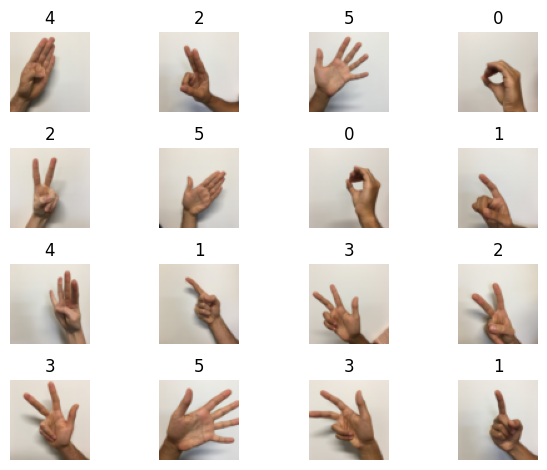

In [24]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None: 
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows): 
        for j in range (n_cols):
            index = n_rows*i+j           
            ax = plt.subplot(n_rows,n_cols,index+1) 
            plt.imshow(X[indices[index]].reshape(64, 64, 3))
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

    plt.tight_layout(h_pad=1)

plt.figure()

display_samples_in_grid(X_train, n_rows=4, y= y_train)

In [28]:
plt.gcf().suptitle('Train set')

Text(0.5, 0.98, 'Train set')

<Figure size 640x480 with 0 Axes>

In [29]:
from sklearn.svm import SVC

In [30]:
clf = SVC(C=10, kernel='rbf', gamma=0.001).fit(X_train_scaled, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test_scaled, y_test)))

train accuracy= 99.907%
test accuracy= 95.833%
